Found 2 dataset(s): ['mmlu_pro', 'mt_bench_human_judgments']
Found 5 model(s): ['Qwen/Qwen3-30B-A3B-Instruct-2507', 'Qwen/Qwen3-Next-80B-A3B-Instruct-FP8', 'Qwen/Qwen3-Next-80B-A3B-Thinking-FP8', 'google/gemma-3-27b-it', 'meta-llama/Llama-3.1-8B-Instruct']


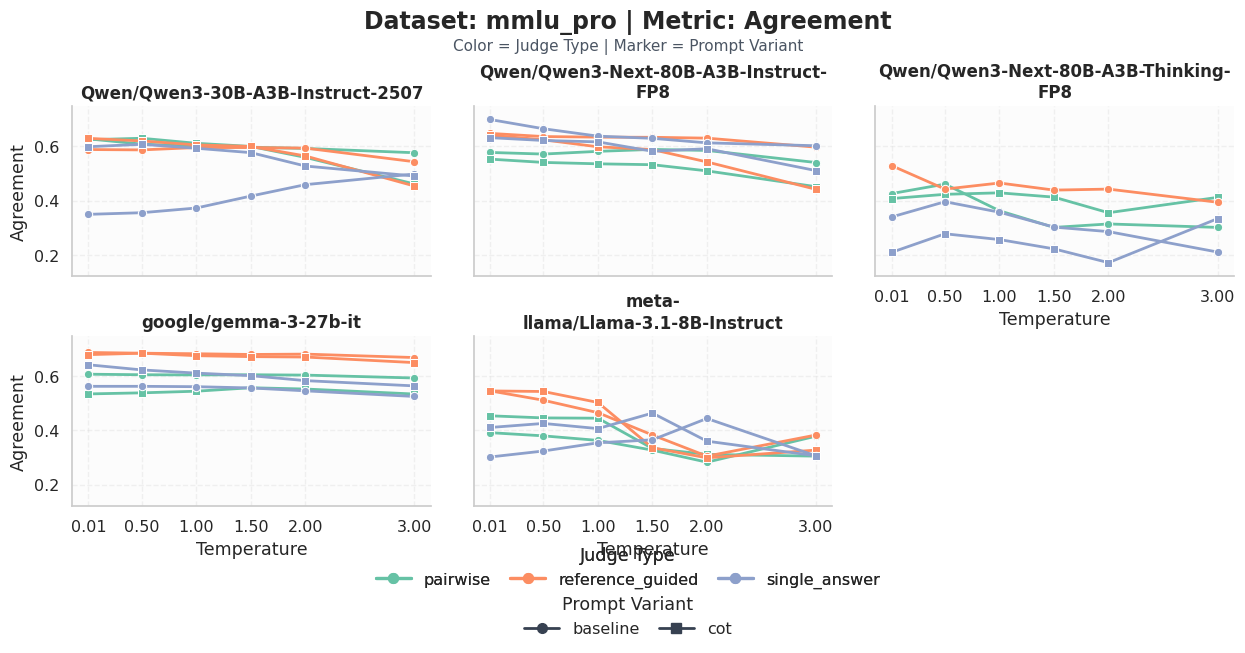

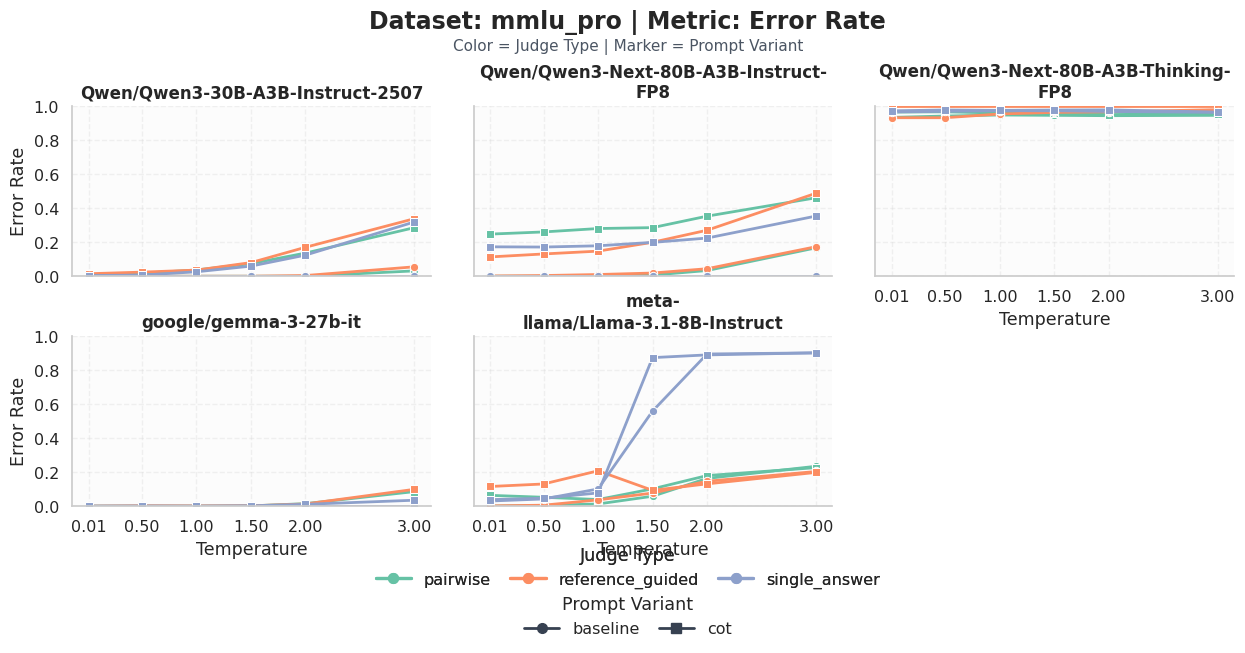

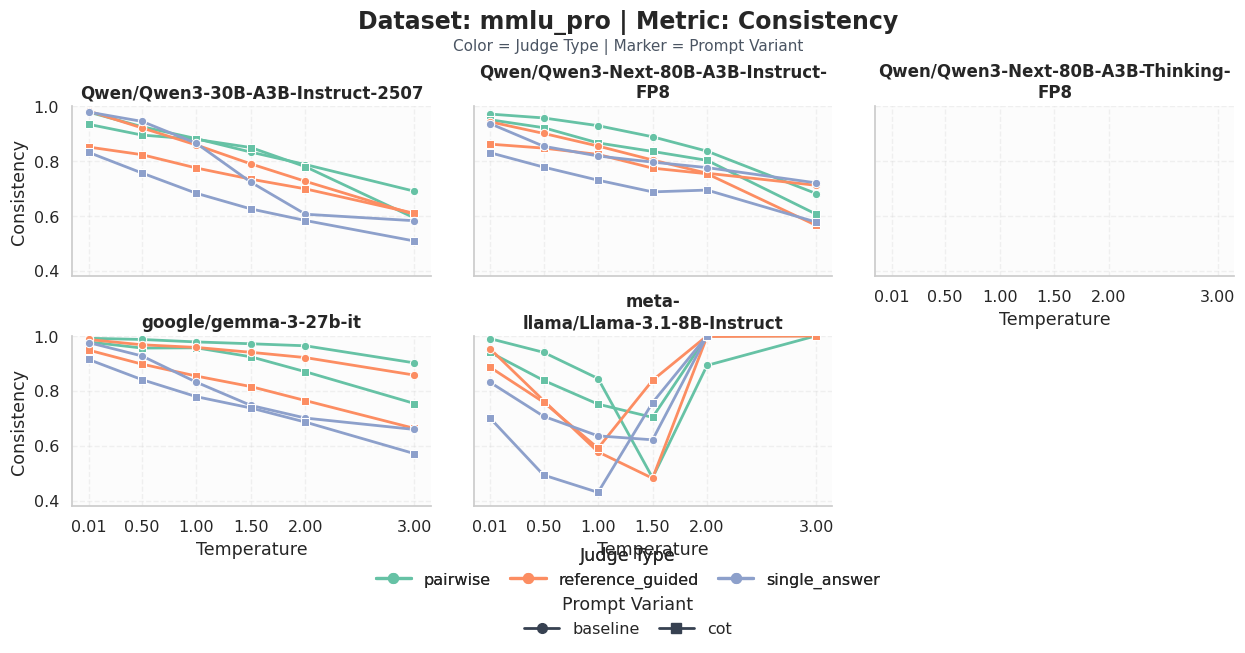

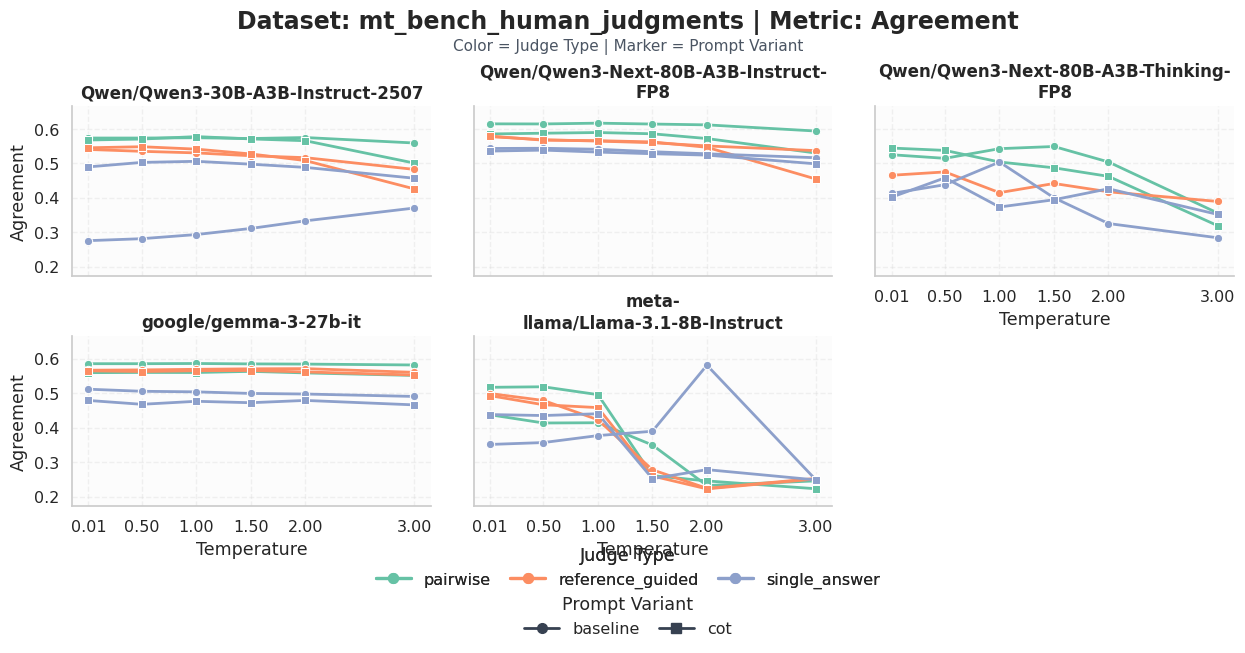

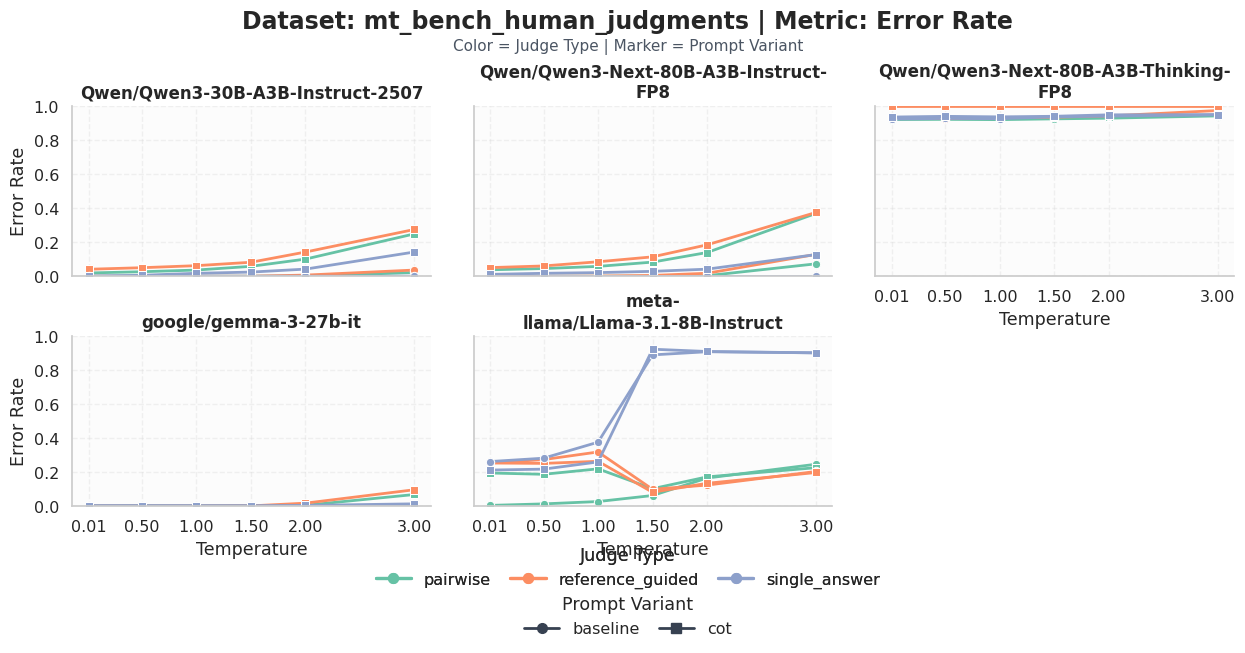

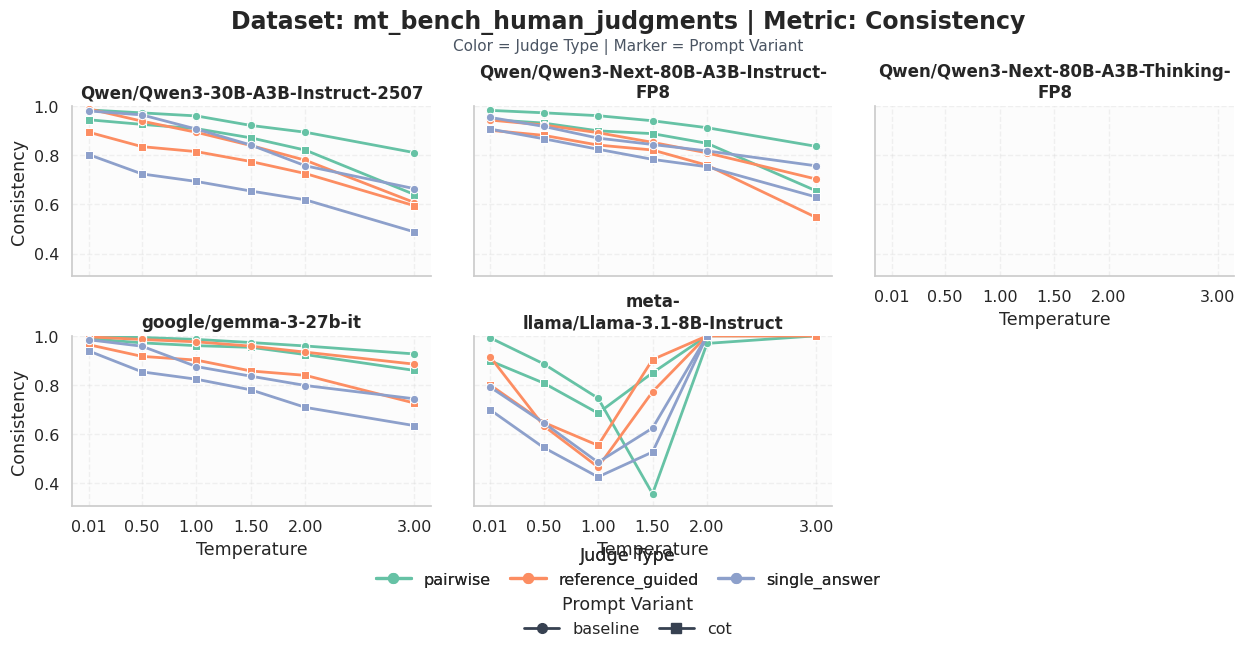

In [2]:
from pathlib import Path
import textwrap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05,
    rc={
        "axes.facecolor": "#FCFCFC",
        "figure.facecolor": "#FFFFFF",
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
    },
)

output_dir = Path("output")
jsonl_paths = sorted(output_dir.glob("evaluation_by_condition_*.jsonl"))
if not jsonl_paths:
    raise FileNotFoundError("No evaluation_by_condition_*.jsonl files found in output/")


def parse_model_name(path: Path) -> str:
    suffix = path.stem.replace("evaluation_by_condition_", "", 1)
    if "__" in suffix:
        provider, model_name = suffix.split("__", 1)
        return f"{provider}/{model_name}"
    return suffix


def display_model_name(model_name: str, width: int = 28) -> str:
    return textwrap.fill(model_name, width=width, break_long_words=False)


frames = []
for path in jsonl_paths:
    frame = pd.read_json(path, lines=True)
    frame["model"] = parse_model_name(path)
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
df["temperature"] = pd.to_numeric(df["temperature"], errors="coerce")
df = df.dropna(subset=["temperature"])

df["model_display"] = df["model"].map(display_model_name)

metric_map = {
    "agreement": "Agreement",
    "error_rate": "Error Rate",
    "consistency": "Consistency",
}
required_cols = [
    "dataset",
    "judge_type",
    "prompt_variant",
    "temperature",
    "model",
    "model_display",
    *metric_map.keys(),
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

plot_df = (
    df.groupby(
        [
            "dataset",
            "model",
            "model_display",
            "judge_type",
            "prompt_variant",
            "temperature",
        ],
        as_index=False,
    )[list(metric_map.keys())]
    .mean(numeric_only=True)
    .sort_values(
        [
            "dataset",
            "model",
            "judge_type",
            "prompt_variant",
            "temperature",
        ]
    )
)

datasets = sorted(plot_df["dataset"].dropna().unique().tolist())
print(f"Found {len(datasets)} dataset(s): {datasets}")
print(f"Found {plot_df['model'].nunique()} model(s): {sorted(plot_df['model'].unique().tolist())}")

for dataset_name in datasets:
    data_subset = plot_df[plot_df["dataset"] == dataset_name].copy()

    model_order = [
        display_model_name(model_name)
        for model_name in sorted(data_subset["model"].dropna().unique().tolist())
    ]
    judge_order = sorted(data_subset["judge_type"].dropna().unique().tolist())
    prompt_order = sorted(data_subset["prompt_variant"].dropna().unique().tolist())
    temp_ticks = sorted(data_subset["temperature"].dropna().unique().tolist())

    judge_palette = dict(
        zip(judge_order, sns.color_palette("Set2", n_colors=len(judge_order)))
    )
    marker_pool = ["o", "s", "D", "^", "P", "X", "v", "*"]
    marker_map = {
        prompt_name: marker_pool[idx % len(marker_pool)]
        for idx, prompt_name in enumerate(prompt_order)
    }

    for metric, metric_label in metric_map.items():
        metric_values = data_subset[metric].dropna()
        if metric_values.empty:
            y_min, y_max = 0.0, 1.0
        else:
            y_min = max(0.0, float(metric_values.min()) - 0.05)
            y_max = min(1.0, float(metric_values.max()) + 0.05)
            if y_max - y_min < 0.12:
                center = (y_min + y_max) / 2
                y_min = max(0.0, center - 0.06)
                y_max = min(1.0, center + 0.06)

        g = sns.relplot(
            data=data_subset,
            x="temperature",
            y=metric,
            col="model_display",
            col_order=model_order,
            col_wrap=3,
            kind="line",
            hue="judge_type",
            hue_order=judge_order,
            palette=judge_palette,
            style="prompt_variant",
            style_order=prompt_order,
            markers=marker_map,
            dashes=False,
            linewidth=2.0,
            errorbar=None,
            legend=False,
            height=3.45,
            aspect=1.22,
            facet_kws={"sharex": True, "sharey": True},
        )

        g.set_titles("{col_name}", size=12, weight="semibold")
        g.set_axis_labels("Temperature", metric_label)

        for ax in g.axes.flatten():
            ax.set_xticks(temp_ticks)
            ax.set_ylim(y_min, y_max)
            ax.grid(True)

        fig = g.figure
        fig.subplots_adjust(top=0.82, bottom=0.24, left=0.06, right=0.98, hspace=0.35, wspace=0.12)

        fig.suptitle(
            f"Dataset: {dataset_name} | Metric: {metric_label}",
            fontsize=17,
            fontweight="bold",
            y=0.96,
        )
        fig.text(
            0.5,
            0.90,
            "Color = Judge Type | Marker = Prompt Variant",
            ha="center",
            fontsize=11,
            color="#4B5563",
        )

        judge_handles = [
            Line2D(
                [0],
                [0],
                color=judge_palette[judge],
                marker="o",
                lw=2.3,
                label=judge,
                markersize=7,
            )
            for judge in judge_order
        ]
        prompt_handles = [
            Line2D(
                [0],
                [0],
                color="#374151",
                marker=marker_map[prompt_name],
                lw=2.0,
                label=prompt_name,
                markersize=7,
            )
            for prompt_name in prompt_order
        ]

        judge_legend = fig.legend(
            handles=judge_handles,
            title="Judge Type",
            loc="lower center",
            bbox_to_anchor=(0.5, 0.10),
            ncol=max(1, min(len(judge_handles), 4)),
            frameon=False,
            handlelength=2.2,
            columnspacing=1.2,
        )
        fig.add_artist(judge_legend)
        fig.legend(
            handles=prompt_handles,
            title="Prompt Variant",
            loc="lower center",
            bbox_to_anchor=(0.5, 0.03),
            ncol=max(1, min(len(prompt_handles), 4)),
            frameon=False,
            handlelength=2.2,
            columnspacing=1.2,
        )

        sns.despine(fig=fig, left=False, bottom=False)
        plt.show()